# Temporal evolution & network analysis (RQ2 / RQ3)

Needs `features.parquet`, `feature_groups.json`, `title_embeddings.npy`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE    = '/content/drive/MyDrive/Social_Media_Mining_Project'
OUT_DIR = f'{BASE}/outputs/'
FIG_DIR = f'{BASE}/figures/'

Mounted at /content/drive


In [2]:
!pip install bertopic umap-learn hdbscan -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.2 MB/s eta 0:00:00


In [3]:
import os, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import kruskal
from bertopic import BERTopic

def set_all_seeds(seed=6):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
set_all_seeds(6)

In [4]:
df = pd.read_parquet(f'{OUT_DIR}features.parquet')
with open(f'{OUT_DIR}feature_groups.json') as f:
    FEATURE_GROUPS = json.load(f)

embeddings = np.load(f'{OUT_DIR}title_embeddings.npy')
print('df:', df.shape, '  embeddings:', embeddings.shape)

df: (49238, 102)   embeddings: (49238, 384)


## Year-stratified SHAP feature importance (RQ2)

In [5]:
import shap

year_counts = df['year'].value_counts()
valid_years = sorted(year_counts[year_counts >= 100].index.tolist())
print('Years with >= 100 posts:', valid_years)

ALL_FEATURES = (
    FEATURE_GROUPS['text_lexical'] +
    FEATURE_GROUPS['text_semantic'] +
    FEATURE_GROUPS['structural']
)

XGB_PARAMS = dict(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=6,
    n_jobs=-1, verbosity=0
)

year_shap_results = {}

for yr in valid_years:
    yr_df = df[df['year'] == yr].reset_index(drop=True)
    X_yr  = yr_df[ALL_FEATURES].fillna(0).values
    y_yr  = yr_df['engagement_score'].values

    if len(yr_df) < 50:
        print(f'  Year {yr}: too few posts, skipping')
        continue

    split = int(len(yr_df) * 0.8)
    X_tr, X_te = X_yr[:split], X_yr[split:]
    y_tr, y_te = y_yr[:split], y_yr[split:]

    reg = XGBRegressor(**XGB_PARAMS)
    reg.fit(X_tr, y_tr)
    r2 = r2_score(y_te, reg.predict(X_te))

    explainer = shap.TreeExplainer(reg)
    shap_vals = np.abs(explainer.shap_values(X_te)).mean(axis=0)

    year_shap_results[yr] = pd.Series(shap_vals, index=ALL_FEATURES)
    print(f'  Year {yr}: n={len(yr_df)}  R2={r2:.3f}')

shap_by_year = pd.DataFrame(year_shap_results).T
print('\nShap by year shape:', shap_by_year.shape)

Years with >= 100 posts: [2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0]
  Year 2014.0: n=167  R2=0.649
  Year 2015.0: n=600  R2=0.421
  Year 2016.0: n=1744  R2=0.725
  Year 2017.0: n=6254  R2=0.833
  Year 2018.0: n=8029  R2=0.894
  Year 2019.0: n=8218  R2=0.882
  Year 2020.0: n=11033  R2=0.868
  Year 2021.0: n=6086  R2=0.841
  Year 2022.0: n=3911  R2=0.825
  Year 2023.0: n=1580  R2=0.779
  Year 2024.0: n=623  R2=0.563

Shap by year shape: (11, 77)


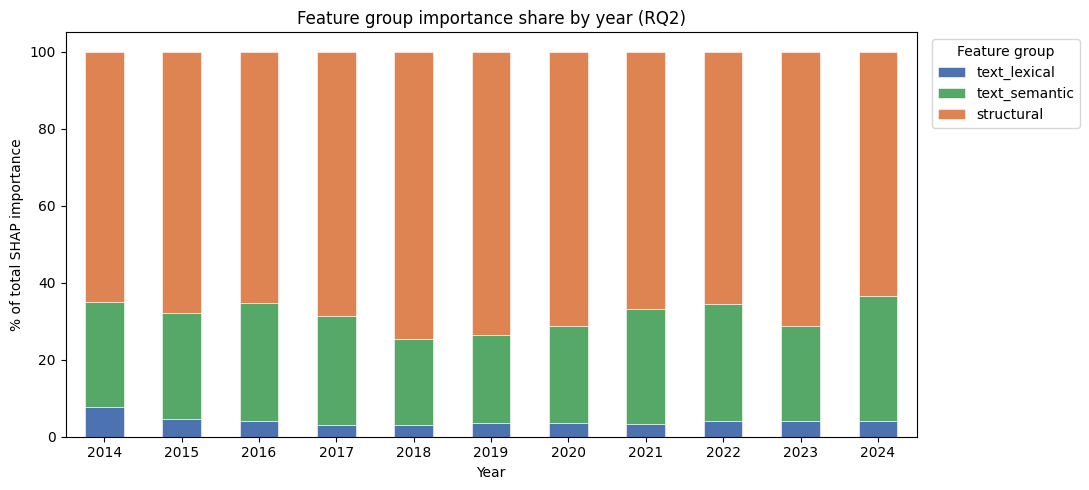

        text_lexical  text_semantic  structural
2014.0          7.72      27.270000   65.010002
2015.0          4.65      27.350000   67.989998
2016.0          4.06      30.740000   65.199997
2017.0          3.07      28.160000   68.769997
2018.0          2.95      22.430000   74.620003
2019.0          3.52      22.930000   73.550003
2020.0          3.48      25.400000   71.120003
2021.0          3.22      29.830000   66.959999
2022.0          4.04      30.530001   65.430000
2023.0          4.00      24.629999   71.370003
2024.0          4.05      32.520000   63.430000


In [6]:
group_shap_year = {}
for grp, cols in FEATURE_GROUPS.items():
    existing = [c for c in cols if c in shap_by_year.columns]
    group_shap_year[grp] = shap_by_year[existing].sum(axis=1)

group_shap_df  = pd.DataFrame(group_shap_year)
group_shap_pct = group_shap_df.div(group_shap_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
group_shap_pct.plot(kind='bar', stacked=True, ax=ax,
                    color=['#4C72B0','#55A868','#DD8452'], edgecolor='white', lw=0.4)
ax.set_title('Feature group importance share by year (RQ2)')
ax.set_xlabel('Year'); ax.set_ylabel('% of total SHAP importance')
ax.set_xticklabels(group_shap_pct.index.astype(int), rotation=0)
ax.legend(title='Feature group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}05_feature_importance_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(group_shap_pct.round(2))

## Crosspost network + power-law analysis

Nodes: 50  |  Edges: 1225
Density: 1.0000
Average clustering coefficient: 0.1874
Average path length: 1.0000
Diameter: 1

Power-law exponent alpha = 2.261
R2 of log-log fit        = 0.9085
Scale-free: yes  (alpha in [2,4] = Barabasi-Albert)

Top 10 by betweenness centrality:
                     betweenness_centrality  degree_centrality  \
askscience                           0.7049                1.0   
Art                                  0.0000                1.0   
DIY                                  0.0000                1.0   
Documentaries                        0.0000                1.0   
EarthPorn                            0.0000                1.0   
Futurology                           0.0000                1.0   
GetMotivated                         0.0000                1.0   
IAmA                                 0.0000                1.0   
InternetIsBeautiful                  0.0000                1.0   
Jokes                                0.0000                1.0  

/tmp/ipykernel_1578/1831403577.py:69: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_dc, p_dc = spearmanr(centrality_df['degree_centrality'],      centrality_df['mean_engagement'])


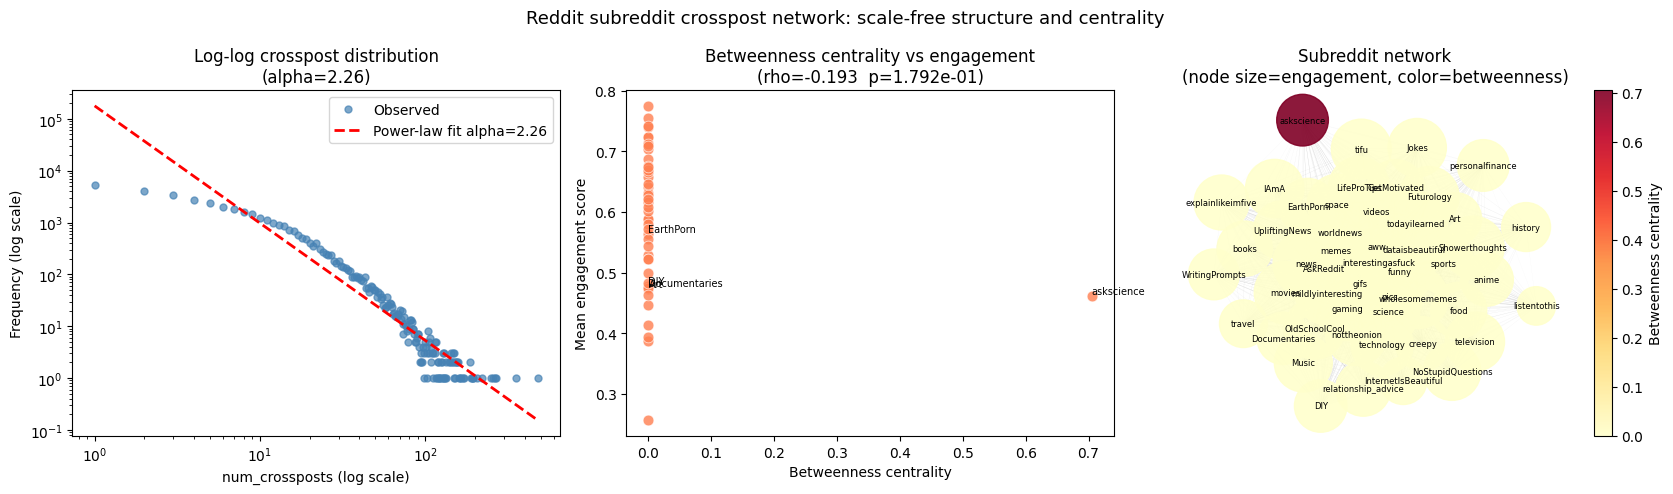

In [7]:
import networkx as nx
from scipy.stats import spearmanr
from collections import Counter

sub_stats = df.groupby('subreddit').agg(
    mean_crossposts=('num_crossposts', 'mean'),
    total_crossposts=('num_crossposts', 'sum'),
    mean_engagement=('engagement_score', 'mean'),
    viral_rate=('is_viral', 'mean'),
    n_posts=('id', 'count')
)

G = nx.Graph()
subreddits = list(sub_stats.index)
G.add_nodes_from(subreddits)

for node in subreddits:
    G.nodes[node]['mean_engagement'] = sub_stats.loc[node, 'mean_engagement']
    G.nodes[node]['viral_rate']      = sub_stats.loc[node, 'viral_rate']
    G.nodes[node]['mean_crossposts'] = sub_stats.loc[node, 'mean_crossposts']

for i, sub_a in enumerate(subreddits):
    for sub_b in subreddits[i+1:]:
        wa = sub_stats.loc[sub_a, 'mean_crossposts']
        wb = sub_stats.loc[sub_b, 'mean_crossposts']
        weight = float(np.sqrt(wa * wb))
        if weight > 0:
            G.add_edge(sub_a, sub_b, weight=weight)

print(f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Average clustering coefficient: {nx.average_clustering(G, weight='weight'):.4f}")
if nx.is_connected(G):
    print(f"Average path length: {nx.average_shortest_path_length(G):.4f}")
    print(f"Diameter: {nx.diameter(G)}")

cross_nonzero = df[df['num_crossposts'] > 0]['num_crossposts']
cross_counts  = cross_nonzero.value_counts().sort_index()

log_x = np.log(cross_counts.index.values.astype(float))
log_y = np.log(cross_counts.values.astype(float))
slope, intercept, r_val, p_val, _ = __import__('scipy').stats.linregress(log_x, log_y)
alpha = -slope

print(f"\nPower-law exponent alpha = {alpha:.3f}")
print(f"R2 of log-log fit        = {r_val**2:.4f}")
print(f"Scale-free: {'yes' if 2 < alpha < 4 else 'no'}  (alpha in [2,4] = Barabasi-Albert)")

degree_cent  = nx.degree_centrality(G)
between_cent = nx.betweenness_centrality(G, weight='weight')
eigen_cent   = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)

centrality_df = pd.DataFrame({
    'degree_centrality':      degree_cent,
    'betweenness_centrality': between_cent,
    'eigenvector_centrality': eigen_cent,
    'mean_engagement':        sub_stats['mean_engagement'],
    'viral_rate':             sub_stats['viral_rate'],
    'mean_crossposts':        sub_stats['mean_crossposts'],
}).sort_values('betweenness_centrality', ascending=False)

print("\nTop 10 by betweenness centrality:")
print(centrality_df[['betweenness_centrality','degree_centrality',
                      'eigenvector_centrality','mean_engagement',
                      'viral_rate']].head(10).round(4))

rho_bc, p_bc = spearmanr(centrality_df['betweenness_centrality'], centrality_df['mean_engagement'])
rho_ec, p_ec = spearmanr(centrality_df['eigenvector_centrality'], centrality_df['mean_engagement'])
rho_dc, p_dc = spearmanr(centrality_df['degree_centrality'],      centrality_df['mean_engagement'])
print(f"\nBetweenness vs engagement: rho={rho_bc:.4f}  p={p_bc:.4e}")
print(f"Eigenvector vs engagement: rho={rho_ec:.4f}  p={p_ec:.4e}")
print(f"Degree vs engagement:      rho={rho_dc:.4f}  p={p_dc:.4e}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].loglog(cross_counts.index, cross_counts.values,
               'o', color='steelblue', ms=5, alpha=0.7, label='Observed')
x_fit = np.linspace(log_x.min(), log_x.max(), 200)
axes[0].loglog(np.exp(x_fit), np.exp(intercept + slope * x_fit),
               'r--', lw=2, label=f'Power-law fit alpha={alpha:.2f}')
axes[0].set_title(f'Log-log crosspost distribution\n(alpha={alpha:.2f})')
axes[0].set_xlabel('num_crossposts (log scale)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].legend()

axes[1].scatter(centrality_df['betweenness_centrality'],
                centrality_df['mean_engagement'],
                color='coral', s=60, alpha=0.8, edgecolors='white', lw=0.5)
for sub in centrality_df.head(5).index:
    axes[1].annotate(sub,
                     (centrality_df.loc[sub,'betweenness_centrality'],
                      centrality_df.loc[sub,'mean_engagement']),
                     fontsize=7, ha='left', va='bottom')
axes[1].set_title(f'Betweenness centrality vs engagement\n(rho={rho_bc:.3f}  p={p_bc:.3e})')
axes[1].set_xlabel('Betweenness centrality')
axes[1].set_ylabel('Mean engagement score')

pos = nx.spring_layout(G, seed=6, weight='weight')
node_sizes  = [centrality_df.loc[n,'mean_engagement'] * 3000
               if n in centrality_df.index else 100 for n in G.nodes()]
node_colors = [centrality_df.loc[n,'betweenness_centrality']
               if n in centrality_df.index else 0 for n in G.nodes()]
edges       = G.edges(data=True)
edge_weights = [d['weight'] for _, _, d in edges]
max_w = max(edge_weights) if edge_weights else 1

nx.draw_networkx_edges(G, pos, ax=axes[2],
                       width=[w / max_w * 2 for w in edge_weights],
                       alpha=0.2, edge_color='gray')
sc = nx.draw_networkx_nodes(G, pos, ax=axes[2],
                             node_size=node_sizes,
                             node_color=node_colors,
                             cmap='YlOrRd', alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=axes[2], font_size=6)
plt.colorbar(sc, ax=axes[2], label='Betweenness centrality')
axes[2].set_title('Subreddit network\n(node size=engagement, color=betweenness)')
axes[2].axis('off')

plt.suptitle('Reddit subreddit crosspost network: scale-free structure and centrality',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}05_crosspost_network_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## BERTopic — topic evolution over time (RQ2)

In [8]:
titles     = df['title'].fillna('').astype(str).tolist()
timestamps = df['created_utc'].dt.to_pydatetime().tolist()

topic_model = BERTopic(
    language='english',
    calculate_probabilities=False,
    verbose=True,
    min_topic_size=30,
    nr_topics='auto'
)

topics, probs = topic_model.fit_transform(titles, embeddings)
df['topic'] = topics

print(f'\nNumber of topics found: {len(topic_model.get_topic_info())}')
print('\nTop topics:')
print(topic_model.get_topic_info().head(15).to_string())

2026-05-04 02:26:04,394 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 02:27:14,776 - BERTopic - Dimensionality - Completed ✓
2026-05-04 02:27:14,778 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 02:27:22,475 - BERTopic - Cluster - Completed ✓
2026-05-04 02:27:22,476 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-04 02:27:23,265 - BERTopic - Representation - Completed ✓
2026-05-04 02:27:23,268 - BERTopic - Topic reduction - Reducing number of topics
2026-05-04 02:27:23,547 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 02:27:25,705 - BERTopic - Representation - Completed ✓
2026-05-04 02:27:25,717 - BERTopic - Topic reduction - Reduced number of topics from 167 to 109



Number of topics found: 109

Top topics:
    Topic  Count                                  Name                                                                             Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

Valid: 48253 titles, 48253 timestamps, 48253 topics


10it [00:02,  4.50it/s]


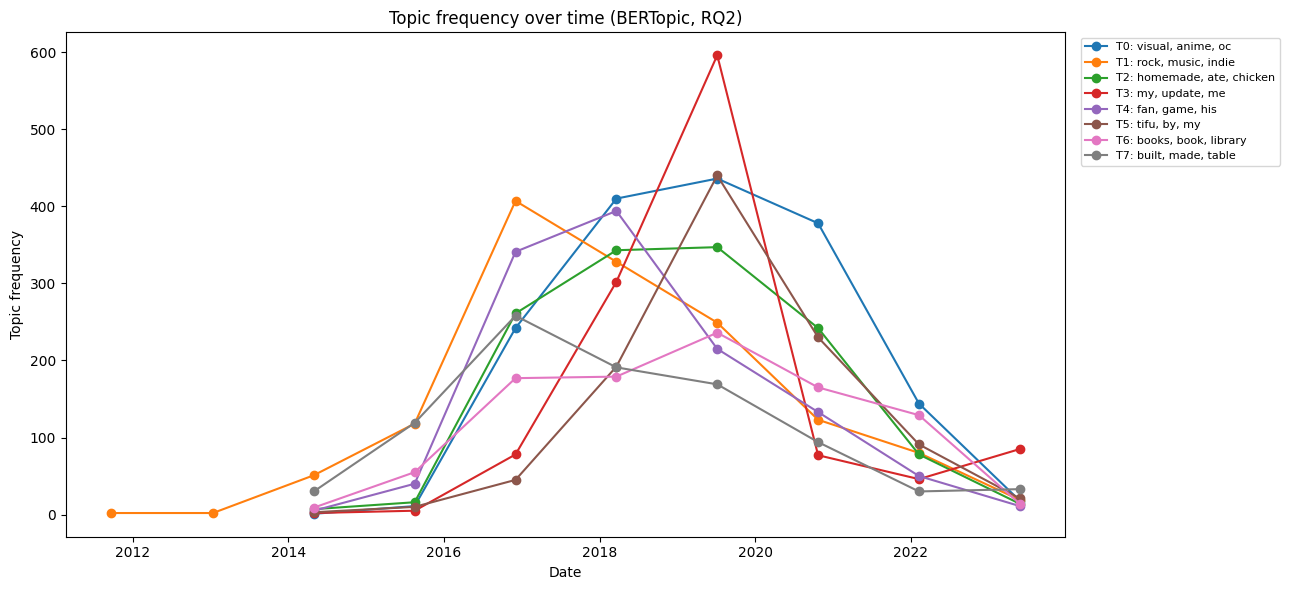

In [9]:
valid_mask = df['created_utc'].notna().values

titles_valid     = [t  for t,  v in zip(titles,     valid_mask) if v]
timestamps_valid = [ts for ts, v in zip(timestamps, valid_mask) if v]
topics_valid     = [tp for tp, v in zip(topics,     valid_mask) if v]

print(f'Valid: {len(titles_valid)} titles, {len(timestamps_valid)} timestamps, {len(topics_valid)} topics')

topics_over_time = topic_model.topics_over_time(
    titles_valid, timestamps_valid, topics_valid, nr_bins=10, evolution_tuning=False
)

top_topic_ids = topic_model.get_topic_info()[1:9]['Topic'].tolist()
tot_filtered  = topics_over_time[topics_over_time['Topic'].isin(top_topic_ids)]

fig, ax = plt.subplots(figsize=(13, 6))
for tid, grp in tot_filtered.groupby('Topic'):
    label = ', '.join([w for w, _ in topic_model.get_topic(tid)[:3]])
    ax.plot(grp['Timestamp'], grp['Frequency'], marker='o', label=f'T{tid}: {label}', lw=1.5)
ax.set_title('Topic frequency over time (BERTopic, RQ2)')
ax.set_xlabel('Date'); ax.set_ylabel('Topic frequency')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}05_topics_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
topic_eng = df[df['topic'] >= 0].groupby('topic').agg(
    mean_eng=('engagement_score','mean'),
    viral_rate=('is_viral','mean'),
    count=('id','count')
).sort_values('mean_eng', ascending=False).head(15)

topic_eng['top_words'] = topic_eng.index.map(
    lambda t: ', '.join([w for w, _ in topic_model.get_topic(t)[:4]])
)
print('\nTop topics by engagement:')
print(topic_eng[['top_words','mean_eng','viral_rate','count']].round(4).to_string())


Top topics by engagement:
                                top_words  mean_eng  viral_rate  count
topic                                                                 
101           blizzard, ea, kong, prohong    0.7159      0.7273     33
39     presidential, election, biden, joe    0.7021      0.5304    115
90               2020, year, what, decade    0.6919      0.5116     43
92                sign, neon, local, this    0.6906      0.4872     39
29        ukraine, russia, russian, putin    0.6901      0.6233    300
93            dumb, smarter, smart, idiot    0.6854      0.3846     39
52        abortion, roe, women, abortions    0.6850      0.4096     83
47       hong, kong, protesters, protests    0.6848      0.6383     94
25                 dad, joke, what, thing    0.6831      0.4436    390
78                   ill, human, hey, see    0.6814      0.3846     52
15     police, officers, officer, capitol    0.6785      0.5045    670
106                 tiktok, ban, us, says    0.678

## Subreddit clustering (RQ3)

In [11]:
STRUCT_FEATS = [
    'title_len','title_word_count','title_caps_ratio','title_has_question',
    'title_has_exclaim','title_readability','sentiment_compound',
    'is_external_link','has_body_text','num_crossposts',
    'engagement_score','is_viral'
]

ptype_cols = [c for c in df.columns if c.startswith('ptype_')]
STRUCT_FEATS += ptype_cols

sub_matrix = df.groupby('subreddit')[STRUCT_FEATS].mean()
print('Subreddit matrix shape:', sub_matrix.shape)
print(sub_matrix.head())

Subreddit matrix shape: (50, 16)
                title_len  title_word_count  title_caps_ratio  \
subreddit                                                       
Art             44.926855          6.979101          0.087495   
AskReddit       94.720812         17.260914          0.025200   
DIY             66.084093         12.265451          0.061895   
Documentaries  171.722054         28.310171          0.058635   
EarthPorn       90.928715         14.760040          0.085056   

               title_has_question  title_has_exclaim  title_readability  \
subreddit                                                                 
Art                      0.000000           0.006270          58.923752   
AskReddit                0.980711           0.007107          73.658864   
DIY                      0.018237           0.152989          71.738314   
Documentaries            0.008056           0.013092          47.235568   
EarthPorn                0.000000           0.054217         

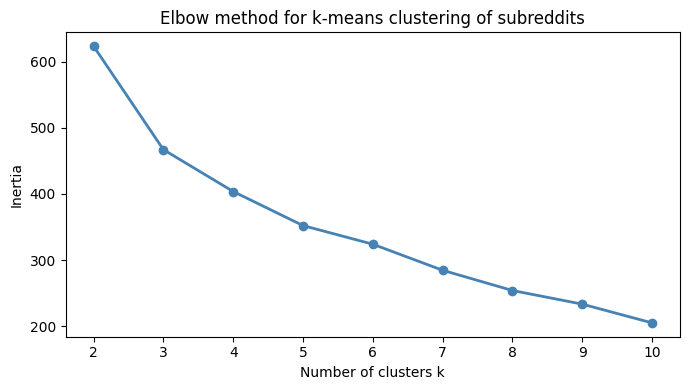

In [12]:
scaler = StandardScaler()
X_sub  = scaler.fit_transform(sub_matrix.fillna(0))

inertias = []
K_RANGE  = range(2, 11)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=6, n_init=10)
    km.fit(X_sub)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_RANGE, inertias, marker='o', color='steelblue', lw=2)
ax.set_title('Elbow method for k-means clustering of subreddits')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Inertia')
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
plt.savefig(f'{FIG_DIR}05_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
K_BEST = 4  # adjust based on elbow

km_final = KMeans(n_clusters=K_BEST, random_state=6, n_init=10)
cluster_labels = km_final.fit_predict(X_sub)
sub_matrix['cluster'] = cluster_labels

print('Subreddits per cluster:')
for c in range(K_BEST):
    members = sub_matrix[sub_matrix['cluster']==c].index.tolist()
    print(f'  Cluster {c}: {members}')

Subreddits per cluster:
  Cluster 0: ['AskReddit', 'IAmA', 'Jokes', 'LifeProTips', 'NoStupidQuestions', 'Showerthoughts', 'WritingPrompts', 'askscience', 'explainlikeimfive', 'personalfinance', 'relationship_advice', 'tifu']
  Cluster 1: ['Art', 'DIY', 'EarthPorn', 'GetMotivated', 'OldSchoolCool', 'anime', 'creepy', 'dataisbeautiful', 'food', 'listentothis', 'space', 'sports', 'travel', 'wholesomememes']
  Cluster 2: ['Documentaries', 'Futurology', 'InternetIsBeautiful', 'Music', 'UpliftingNews', 'books', 'history', 'movies', 'news', 'nottheonion', 'science', 'technology', 'television', 'todayilearned', 'videos', 'worldnews']
  Cluster 3: ['aww', 'funny', 'gaming', 'gifs', 'interestingasfuck', 'memes', 'mildlyinteresting', 'pics']


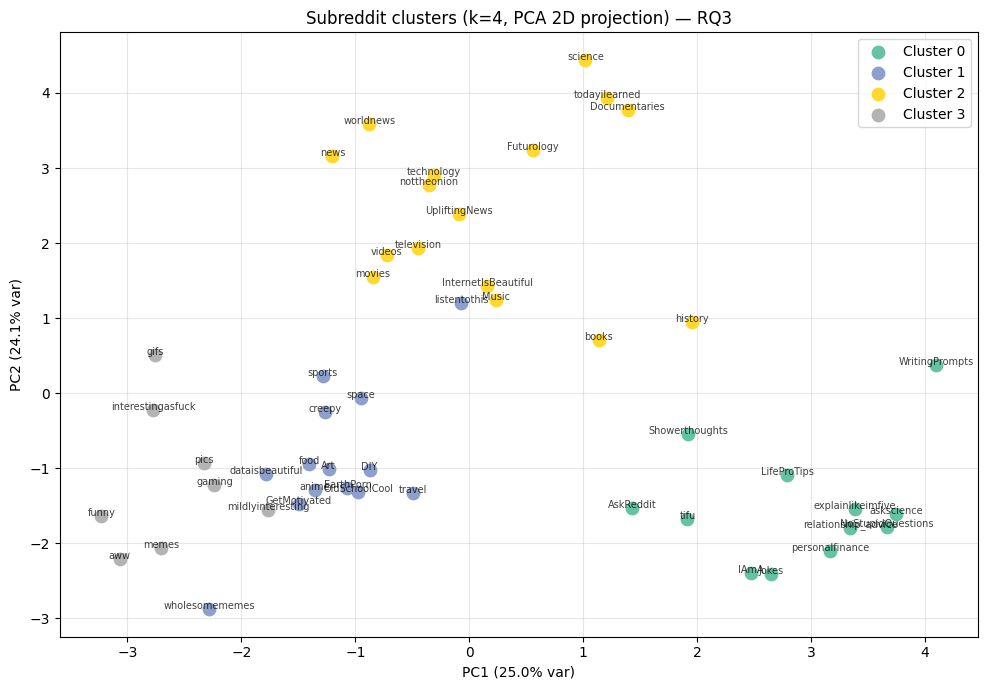

In [14]:
pca2 = PCA(n_components=2, random_state=6)
X_2d = pca2.fit_transform(X_sub)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Set2(np.linspace(0, 1, K_BEST))
for c in range(K_BEST):
    mask = cluster_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], color=colors[c],
               s=80, label=f'Cluster {c}', zorder=3)
    for idx, sub in enumerate(sub_matrix.index):
        if cluster_labels[idx] == c:
            ax.annotate(sub, (X_2d[idx, 0], X_2d[idx, 1]),
                        fontsize=7, alpha=0.75, ha='center')

ax.set_title(f'Subreddit clusters (k={K_BEST}, PCA 2D projection) — RQ3')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}05_subreddit_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
df_with_cluster = df.copy()
df_with_cluster['sub_cluster'] = df_with_cluster['subreddit'].map(
    sub_matrix['cluster'].to_dict()
)

cluster_groups = [
    g['engagement_score'].values
    for _, g in df_with_cluster.groupby('sub_cluster')
    if g['engagement_score'].notna().sum() > 0
]
stat, pval = kruskal(*cluster_groups)
print(f'Kruskal-Wallis across clusters: H={stat:.4f}  p={pval:.4e}')
if pval < 0.05:
    print('=> Significant engagement differences across subreddit clusters')
else:
    print('=> No significant difference across clusters')

cluster_summary = df_with_cluster.groupby('sub_cluster').agg(
    mean_engagement=('engagement_score','mean'),
    viral_rate=('is_viral','mean'),
    mean_sentiment=('sentiment_compound','mean'),
    mean_question=('title_has_question','mean'),
    n_posts=('id','count')
).round(4)
print('\nCluster engagement summary:')
print(cluster_summary.to_string())

cluster_summary.to_csv(f'{OUT_DIR}cluster_summary.csv')

Kruskal-Wallis across clusters: H=15540.0014  p=0.0000e+00
=> Significant engagement differences across subreddit clusters

Cluster engagement summary:
             mean_engagement  viral_rate  mean_sentiment  mean_question  n_posts
sub_cluster                                                                     
0                     0.5725      0.1168         -0.0064         0.3547    11734
1                     0.5277      0.0206          0.0909         0.0089    13762
2                     0.6099      0.2127         -0.0431         0.0268    15813
3                     0.7158      0.6090          0.0843         0.0221     7929


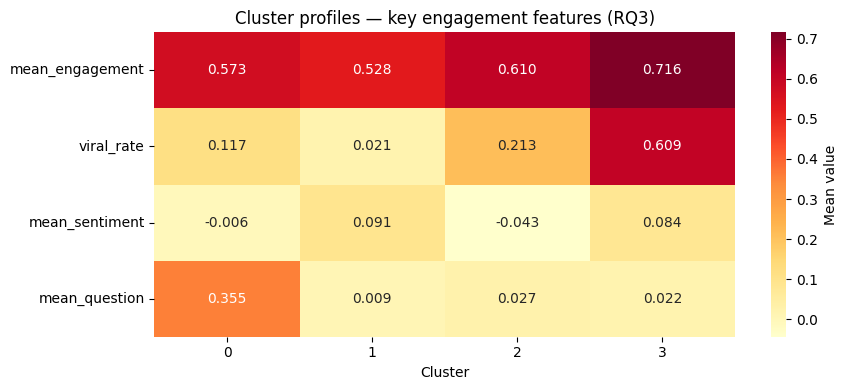

In [16]:
feat_to_show = ['mean_engagement','viral_rate','mean_sentiment','mean_question']
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    cluster_summary[feat_to_show].T,
    annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
    cbar_kws={'label': 'Mean value'}
)
ax.set_title('Cluster profiles — key engagement features (RQ3)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}05_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## Homophily vs social influence (Crandall et al. design — Lecture 23)

Building subreddit-level temporal similarity analysis...
(Crandall et al. design: Lecture 23)
Subreddits with sufficient data in both periods: 48
Subreddit pairs analyzed: 1,128

Homophily test (pre-period similarity):  p=1.4790e-01
Influence test (convergence over time):  p=1.6084e-01
Connectivity -> convergence: rho=0.0342  p=2.5120e-01

Decile analysis:
conn_decile  early_sim  late_sim  convergence   n
  Q1\n(low)  -0.178945 -0.198196    -0.019251 226
         Q2  -0.203141 -0.233424    -0.030284 225
         Q3  -0.203337 -0.229746    -0.026408 226
         Q4  -0.191646 -0.220662    -0.029016 225
 Q5\n(high)  -0.166142 -0.183438    -0.017296 226


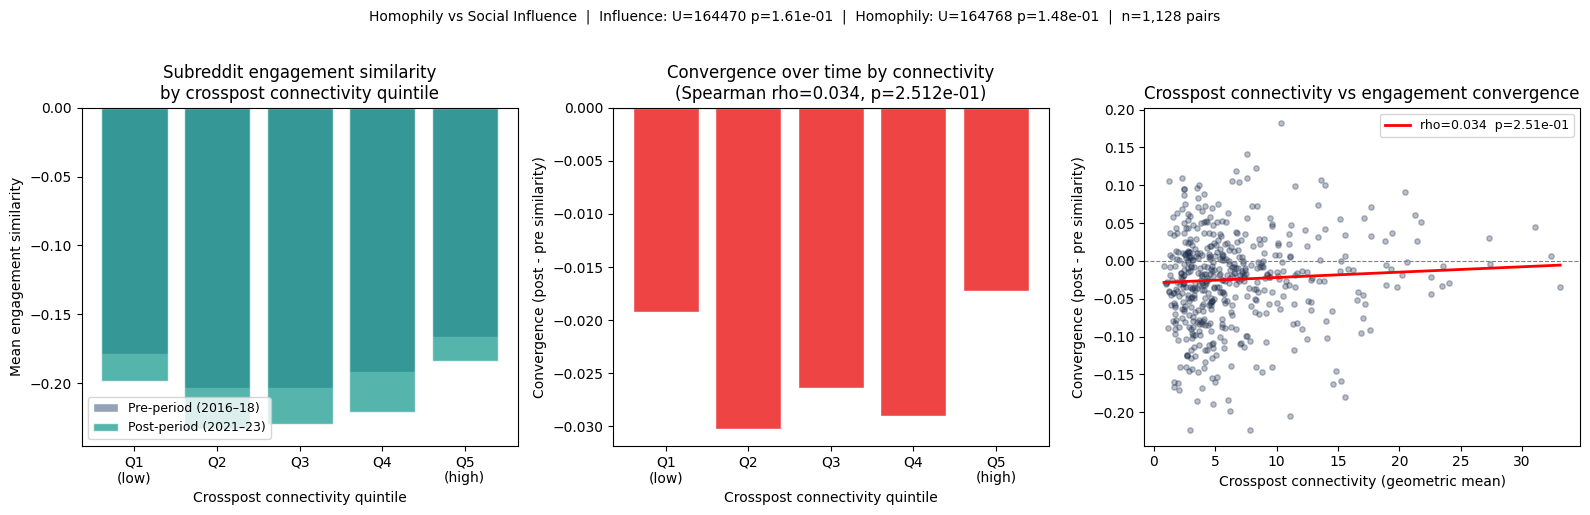

In [17]:
import itertools
from scipy.stats import spearmanr, mannwhitneyu, pearsonr

print("Building subreddit-level temporal similarity analysis...")
print("(Crandall et al. design: Lecture 23)")

EARLY_YEARS = [2016, 2017, 2018]
LATE_YEARS  = [2021, 2022, 2023]

def sub_profile(df_sub, years, metrics):
    mask = df_sub['year'].isin(years)
    if mask.sum() < 10:
        return None
    return df_sub[mask][metrics].mean().values

metrics = ['engagement_score', 'sentiment_compound', 'upvote_ratio']

if 'sentiment_compound' not in df.columns:
    features_df = pd.read_parquet(f'{OUT_DIR}features.parquet')
    df = df.merge(features_df[['id','sentiment_compound']], on='id', how='left')

subreddits = df['subreddit'].unique().tolist()

early_profiles = {}
late_profiles  = {}
for sub in subreddits:
    sub_df = df[df['subreddit'] == sub]
    ep = sub_profile(sub_df, EARLY_YEARS, metrics)
    lp = sub_profile(sub_df, LATE_YEARS,  metrics)
    if ep is not None: early_profiles[sub] = ep
    if lp is not None: late_profiles[sub]  = lp

valid_subs = [s for s in subreddits if s in early_profiles and s in late_profiles]
print(f"Subreddits with sufficient data in both periods: {len(valid_subs)}")

sub_cross = df.groupby('subreddit')['num_crossposts'].mean()

pair_data = []
for s1, s2 in itertools.combinations(valid_subs, 2):
    c1 = sub_cross.get(s1, 0)
    c2 = sub_cross.get(s2, 0)
    connectivity = float(np.sqrt(c1 * c2))

    ep1, ep2 = early_profiles[s1], early_profiles[s2]
    lp1, lp2 = late_profiles[s1],  late_profiles[s2]

    early_sim   = -np.linalg.norm(ep1 - ep2)
    late_sim    = -np.linalg.norm(lp1 - lp2)
    convergence = late_sim - early_sim

    pair_data.append({
        'sub1': s1, 'sub2': s2,
        'connectivity': connectivity,
        'early_similarity': early_sim,
        'late_similarity':  late_sim,
        'convergence': convergence,
    })

pairs_df = pd.DataFrame(pair_data)
print(f"Subreddit pairs analyzed: {len(pairs_df):,}")

med_conn  = pairs_df['connectivity'].median()
high_conn = pairs_df[pairs_df['connectivity'] > med_conn]
low_conn  = pairs_df[pairs_df['connectivity'] <= med_conn]

stat_h, p_h = mannwhitneyu(high_conn['early_similarity'], low_conn['early_similarity'],
                            alternative='greater')
stat_i, p_i = mannwhitneyu(high_conn['convergence'], low_conn['convergence'],
                            alternative='greater')
rho_c, p_c  = spearmanr(pairs_df['connectivity'], pairs_df['convergence'])

print(f"\nHomophily test (pre-period similarity):  p={p_h:.4e}")
print(f"Influence test (convergence over time):  p={p_i:.4e}")
print(f"Connectivity -> convergence: rho={rho_c:.4f}  p={p_c:.4e}")

pairs_df['conn_decile'] = pd.qcut(pairs_df['connectivity'], q=5,
                                   labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
decile_stats = pairs_df.groupby('conn_decile', observed=True).agg(
    early_sim=('early_similarity', 'mean'),
    late_sim=('late_similarity',   'mean'),
    convergence=('convergence',    'mean'),
    n=('convergence',              'count')
).reset_index()
print(f"\nDecile analysis:")
print(decile_stats.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.bar(decile_stats['conn_decile'], decile_stats['early_sim'],
       color='#94A3B8', edgecolor='white', label='Pre-period (2016–18)')
ax.bar(decile_stats['conn_decile'], decile_stats['late_sim'],
       color='#0D9488', edgecolor='white', alpha=0.7, label='Post-period (2021–23)')
ax.set_title('Subreddit engagement similarity\nby crosspost connectivity quintile')
ax.set_xlabel('Crosspost connectivity quintile')
ax.set_ylabel('Mean engagement similarity')
ax.legend(fontsize=9)

ax = axes[1]
colors_conv = ['#EF4444' if v < 0 else '#0D9488' for v in decile_stats['convergence']]
ax.bar(decile_stats['conn_decile'], decile_stats['convergence'],
       color=colors_conv, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'Convergence over time by connectivity\n(Spearman rho={rho_c:.3f}, p={p_c:.3e})')
ax.set_xlabel('Crosspost connectivity quintile')
ax.set_ylabel('Convergence (post - pre similarity)')

ax = axes[2]
sample = pairs_df.sample(min(500, len(pairs_df)), random_state=6)
ax.scatter(sample['connectivity'], sample['convergence'],
           alpha=0.3, s=15, color='#1A2B4A')
x  = pairs_df['connectivity'].values
y  = pairs_df['convergence'].values
z  = np.polyfit(x, y, 1)
xl = np.linspace(x.min(), x.max(), 100)
ax.plot(xl, np.polyval(z, xl), 'r-', lw=2, label=f'rho={rho_c:.3f}  p={p_c:.2e}')
ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.set_title('Crosspost connectivity vs engagement convergence')
ax.set_xlabel('Crosspost connectivity (geometric mean)')
ax.set_ylabel('Convergence (post - pre similarity)')
ax.legend(fontsize=9)

plt.suptitle(
    f'Homophily vs Social Influence  |  '
    f'Influence: U={stat_i:.0f} p={p_i:.2e}  |  '
    f'Homophily: U={stat_h:.0f} p={p_h:.2e}  |  '
    f'n={len(pairs_df):,} pairs',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}05_homophily_vs_influence.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
df_with_cluster.to_parquet(f'{OUT_DIR}final_with_clusters.parquet', index=False)
print('\nAll done!')
print(f'Figures -> {FIG_DIR}')
print(f'Outputs -> {OUT_DIR}')


All done!
Figures -> /content/drive/MyDrive/Social_Media_Mining_Project/figures/
Outputs -> /content/drive/MyDrive/Social_Media_Mining_Project/outputs/
